# Implementation of BLA initiliasation
Goal of this file is to obtain consistent NN models, using the BLA initialisation.
This is done in the following steps:

- Call the datagen to generate a dataset
- <font color='red'>(Optional) MATLAB hook to determine the BLA matrices for that dataset</font>
- Initialise the model with the BLA matrices
- Train the encoder for <font color='red'>(???)</font> epochs
- Freeze encoder parameters and enable NNs for J, R, G, P
- Train the NNs for <font color='red'>(???)</font> epochs
- Save the model and training information

These steps are then followed by a few visualization cells, showing the:
- Training and validation losses
- Qualitative simulation on a test set

In [1]:
# ========== Imports ==========
import os
import torch
import scipy
import numpy as np
import matplotlib.pyplot as plt

from MSD_model import combined_PHNN, cheat_PHNN
from MSD_datagen import generate_data
from utils import *

# Indicate data locations
PATH_MATRICES = "matlabIO/W19_BLA_matrices.mat"
PATH_DATASET = "datasets/W19_3MSD_nonlinear_DS.pt"

# Set figure parameters in advance
plt.rcParams['figure.figsize'] = (15, 3)
plt.rcParams['figure.facecolor'] = "eee8e8"
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

c:\Users\20174290\AppData\Local\miniconda3\envs\portHamiltonian\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Call the datagen to generate a dataset:

In [2]:
# System settings
sim_time = torch.linspace(0, 100, 1000)   # NOTE be careful of sim_time: [0, 100] for dataset, while [0, 1] for matlab
M_vals = torch.FloatTensor([2, 2, 2])
D_vals = torch.FloatTensor([3, 3, 3])
K_vals = torch.FloatTensor([4, 4, 4])
cD_vals = torch.FloatTensor([1, 1, 1])
    
# Import or generate data
if os.path.isfile(PATH_DATASET):
    datasets = torch.load(PATH_DATASET, weights_only=False)
else:
    datasets = generate_data(sim_time, M_vals=M_vals, D_vals=D_vals, K_vals=K_vals, cubic_D=cD_vals, n_datasets=8, freq_band=torch.linspace(0.1, 12, 40))
    torch.save(datasets, PATH_DATASET)

### <font color='red'>(Optional)</font> MATLAB hook to determine the BLA matrices for that dataset:
Note that while the MATLAB matrices are carried over nicely (in terms of precision), their products differ slightly. </br>
For example: </br>
MATLAB ((J-R)*Q)[1, 1] = 12.4077328843393 </br>
PYTHON ((J-R)*Q)[1, 1] = 12.4075

In [3]:
# ========== Automatic ==========
#TODO

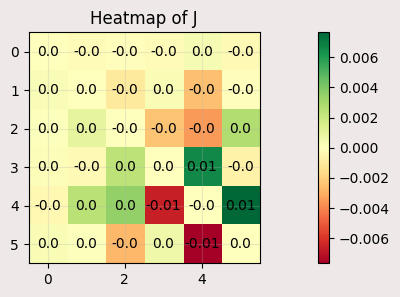

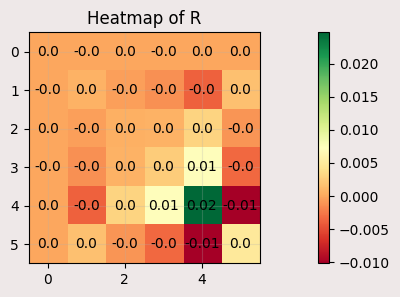

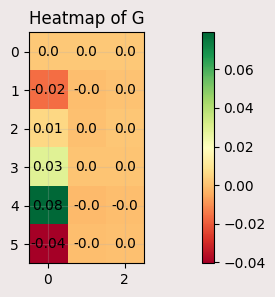

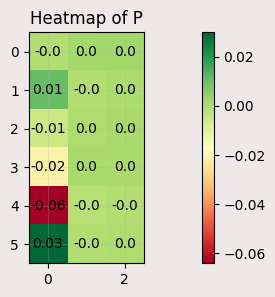

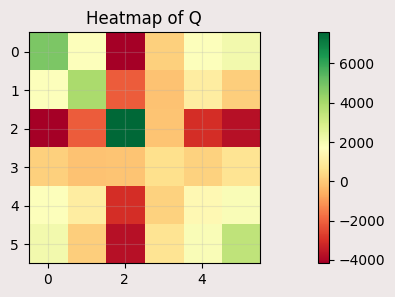

In [4]:
# ========== Manual ==========
# Save the dataset to csv files for matlab to interpret
inputs = datasets[0]["inputs"].numpy()
np.savetxt("matlabIO/_inputs.csv", inputs, delimiter=",")
outputs = datasets[0]["output"].numpy()
np.savetxt("matlabIO/_outputs.csv", outputs, delimiter=",")
n_outputs = datasets[0]["noisy_output"].numpy()
np.savetxt("matlabIO/_noisy_outputs.csv", n_outputs, delimiter=",")

# Import the matrices from MATLAB
matrix_dict = scipy.io.loadmat(PATH_MATRICES)
J = torch.FloatTensor(matrix_dict["J"])
R = torch.FloatTensor(matrix_dict["R"])
G = torch.FloatTensor(matrix_dict["G"])
Q = torch.FloatTensor(matrix_dict["Q"])
P = torch.FloatTensor(matrix_dict["P"])

if True:
    plot_matrix_heatmap(J, "J")
    plot_matrix_heatmap(R, "R")
    plot_matrix_heatmap(G, "G")
    plot_matrix_heatmap(P, "P")
    plot_matrix_heatmap(Q, "Q")
#TODO: subplot for multiple matrix plotting

In [11]:
print(MLP_res_net(input_size=3, output_size=4))
print(feed_forward_nn(3, 4))

MLP_res_net(
  (net_res): Linear(in_features=3, out_features=4, bias=True)
  (net_nonlin): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)
feed_forward_nn(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)


### Initialise the model with the BLA matrices:
MATLAB is trained by predicting on a [0, 1] timewindow , instead of the [0, 100] actual dataset window to prevent y_PH from blowing up.
For now continue with the JRPGQ trained on [0, 1]

In [5]:
# Give the model specifications
x0 = torch.zeros(6)
system_dim = torch.IntTensor([[6, 3]])
na = 10
nb = 10

# TODO: Initialise at NN output = 0
# REWORK deepSI integration
# Perhaps split of the NN part entirely so that encoder training can be much quicker
combined_model = combined_PHNN(system_dim, na, nb, dt=sim_time[1], x0=x0, weight=0,
                               Jinit=J,
                               Rinit=R,
                               Ginit=G,
                               Qinit=Q,
                               Pinit=P,
                               custom_kwargs={})

TypeError: MLP_res_net.__init__() got an unexpected keyword argument 'n_in'

In [2]:
plot_simulation(sim_time, datasets[0]["output"], comb_outputs, plot_mode="error", title="Simulation: BLA initialised model")

NameError: name 'plot_simulation' is not defined

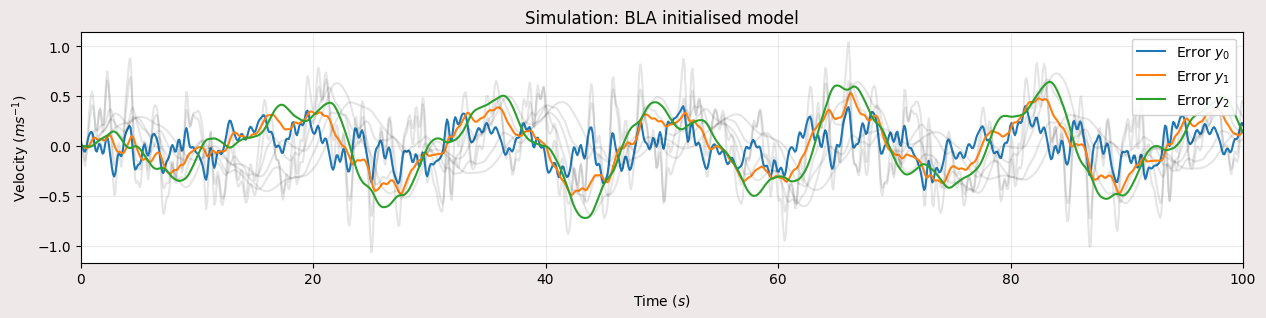

In [56]:
# Qualitative results of the linear model before training
u = datasets[0]["inputs"]   # NB: We are using the first dataset for estimations
comb_states, comb_outputs = simulate_model_withP(sim_time=sim_time, model=combined_model, x0=x0, u_ext=u)
plot_simulation(sim_time, datasets[0]["output"], comb_outputs, plot_mode=1, title="Simulation: BLA initialised model")

### Train the encoder for <font color='red'>(???)</font> epochs

### Temporary visualisations:

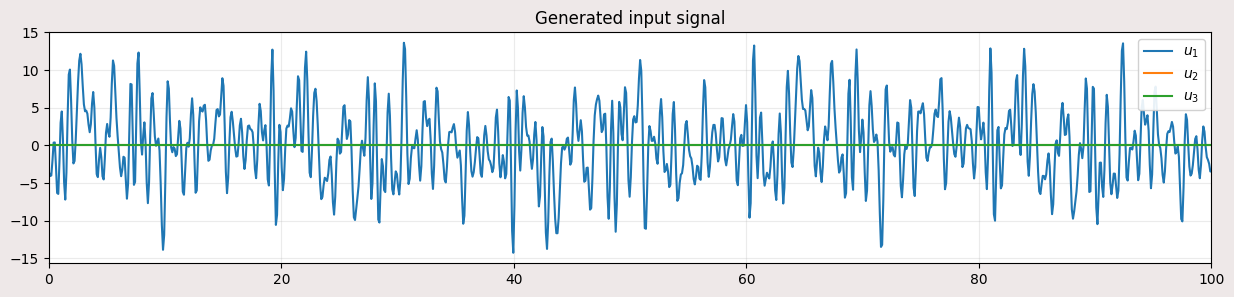

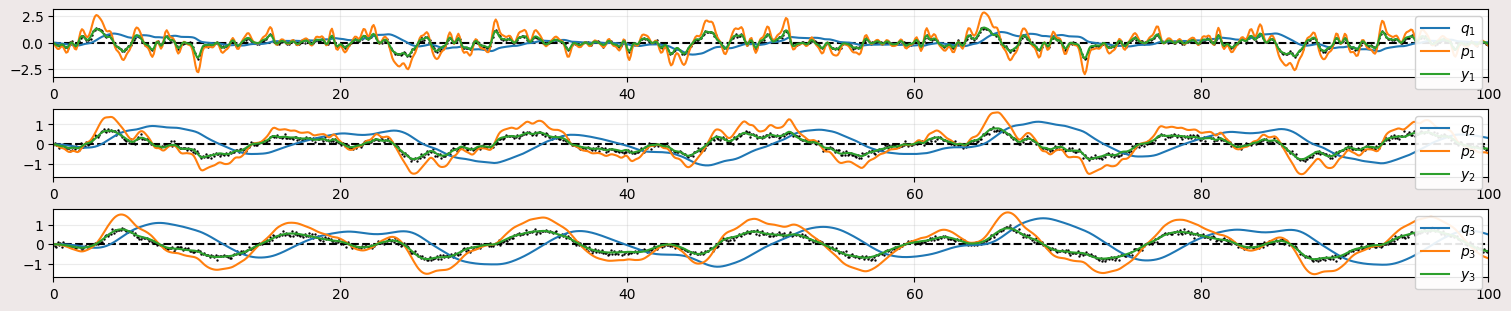

In [15]:
# Check the dataset
nsys=3
z = -1 # Select which dataset should be used for plotting
inputs = datasets[z]["inputs"]
states = datasets[z]["states"]
output = datasets[z]["output"]
if "noisy_output" in datasets[z]:   # Check if the dataset is generated with noise
    noisy_output = datasets[z]["noisy_output"]
else:
    print("No noisy output present in the dataset")

# Plot the system behaviour
fig_input = plt.figure(figsize=(15, 3))
plt.plot(sim_time, inputs)
plt.legend([f"$u_{1}$", f"$u_{2}$", f"$u_{3}$"], loc=1)
plt.title("Generated input signal")
plt.xlim([0, max(sim_time)])         


fig, (ax0, ax1, ax2) = plt.subplots(nsys, 1, layout='constrained') #TODO, automate ax1, ax2, ax3
for i in range(0, nsys):
    # globals()["ax%s" % i] basically says "axi" for looped plotting
    globals()["ax%s" % i].plot(sim_time, torch.zeros_like(sim_time), "k--",label='_nolegend_')  # Plot 0-line
    globals()["ax%s" % i].plot(sim_time, states[:, i])                                          # Plot state q_i
    globals()["ax%s" % i].plot(sim_time, states[:, nsys+i])                                     # Plot state p_i
    globals()["ax%s" % i].plot(sim_time, output[:, i])                                          # Plot output y_i
    if noisy_output is not None:
        globals()["ax%s" % i].scatter(sim_time, noisy_output[:, i], s=0.5, color="black")       # Plot noisy outputs y_1
    globals()["ax%s" % i].legend([f'$q_{i+1}$', f'$p_{i+1}$', f'$y_{i+1}$'], loc=1)             # Add legends
    globals()["ax%s" % i].set_xlim([0, max(sim_time)])                                          # Set xlimits
plt.show()

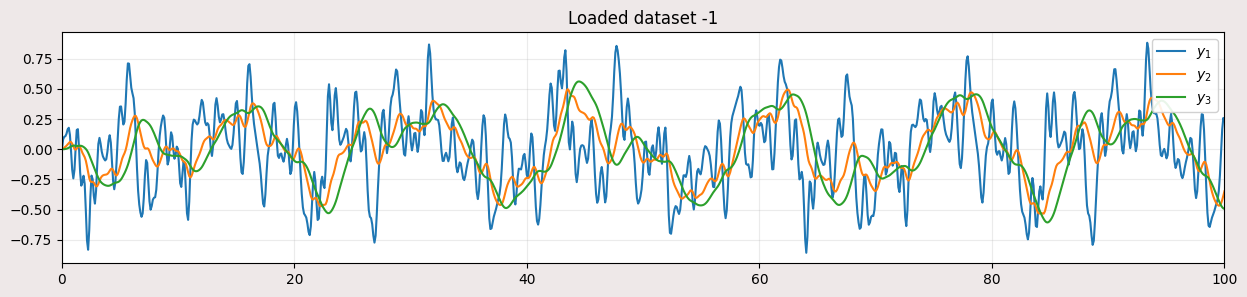

In [15]:
z = -1
plt.plot(sim_time, datasets[z]["output"][:, 0])
plt.plot(sim_time, datasets[z]["output"][:, 1])
plt.plot(sim_time, datasets[z]["output"][:, 2])
plt.legend(["$y_{1}$", "$y_{2}$", "$y_{3}$"], loc=1)
plt.title(f"Loaded dataset {z}")
plt.xlim([0, sim_time[-1]])
plt.show()

### Salvaged from the old file:

In [1]:
# Import the Best Linear Approximation (BLA) of the dataset and check the results:
# NB: this approximation is done through the MATLAB ssest function
matrix_dict = scipy.io.loadmat(PATH_JRGQ)
J = torch.FloatTensor(matrix_dict["J"])
R = torch.FloatTensor(matrix_dict["R"])
G = torch.FloatTensor(matrix_dict["G"])
Q = torch.FloatTensor(matrix_dict["Q"])
P = torch.FloatTensor(matrix_dict["P"])
#print(J, R, G, Q, P)

# Use the MATLAB (linear) datageneration instead:
matlab_data = scipy.io.loadmat(PATH_DATA_MATLAB)
print(matlab_data.keys())
matlab_dsi_IO = Input_output_data(u=matlab_data["u"], y=matlab_data["y_noisy"], sampling_time=(sim_time[1]-sim_time[0]))


# Match the MATLAB dataset
u = torch.FloatTensor(matlab_dsi_IO.u)
datasets[z]["output"] =  torch.FloatTensor(matlab_dsi_IO.y)

# Initialise the model
combined_model = combined_PHNN(system_dim, na, nb, dt=sim_time[1], x0=x_test, weight=0,
                               Jinit=J,
                               Rinit=R,
                               Ginit=G,
                               Qinit=Q,
                               Pinit=P,
                               custom_kwargs={})

# Qualitative results of the linear model before training
comb_states, comb_outputs = simulate_model_withP(sim_time=sim_time, model=combined_model, x0=x0, u_ext=u)
plot_simulation(sim_time, datasets[0]["output"], comb_outputs, plot_mode="error", title="Simulation: BLA initialised model")

# Attempt at only training the encoder:
for name, layer in combined_model.named_children():
    if name == "enc_net":
        for param in layer.parameters():    
            param.requires_grad = True
    else:
        for param in layer.parameters():
            param.requires_grad = False

# Check to see if they are really turned off
for param in combined_model.parameters():
    print(param.requires_grad)

# Train Encoder
cf_loss, cf_val_loss, cf_best_sd = fit_model(combined_model, matlab_dsi_IO, datasets[1]["dsi_IO"], n_its=10001, T=1, val_freq=100)

# Plot Encoder training
plt.semilogy(cf_loss, label="Combined train", color="#6699CC")
plt.semilogy(cf_val_loss, label="Combined val", color="#004488")

plt.ylabel('NRMSE')
plt.legend(loc=1)
plt.xlabel('Iteration')
plt.xlim([0, max(len(lf_loss), len(nlf_loss), len(cf_loss))])
plt.title("BLA Encoder training")
plt.grid(alpha=0.25)
plt.show()

# Plot Encoder performance
from deepSI_lite.models import past_future_arrays
untrained_combined_model = combined_PHNN(system_dim, na, nb, dt=sim_time[1], x0=x_test,
                               Jinit=J,
                               Rinit=R,
                               Ginit=G,
                               Qinit=Q,
                               Pinit=P,
                               custom_kwargs={})


arrays, indices = past_future_arrays(datasets[0]["dsi_IO"], na=combined_model.na, nb=combined_model.nb, T=1, add_sampling_time=False, stride=1) #transform (u, y) into (u1, y1, u2, y2)
arrays[0].shape
t = 0
u1 = arrays[0]#[0, :, :].view(1, arrays[0].shape[1], arrays[0].shape[2])
y1 = arrays[1]#[0, :, :].view(1, arrays[1].shape[1], arrays[1].shape[2])
u2 = arrays[2]#[0, :, :].view(1, arrays[2].shape[1], arrays[2].shape[2])
y2 = arrays[3][:, t, 0]

# model input must be upast, ypast ufuture
ypred = combined_model(u1, y1, u2).detach().numpy()
untrained_ypred = untrained_combined_model(u1, y1, u2).detach().numpy()
plt.plot(sim_time[10:], y2, label="True")
plt.plot(sim_time[10:], ypred[:, t, 0], label="Trained encoder")
plt.plot(sim_time[10:], untrained_ypred[:, t, 0], "k", alpha=0.1, label="Untrained encoder")
plt.ylim([-3, 3])
plt.xlim([0, sim_time[-1]])
plt.title("1-step-ahead prediction")
plt.ylabel("Velocity ($ms^{-1}$)")
plt.xlabel("Time (s)")
plt.legend(loc=1)
plt.show()

# Turn of encoder training, turn on rest of network training:
for param in combined_model.Jnet.net_list[0].net[0].parameters():
    print(param.requires_grad)
    if param.requires_grad:
        print("Parameter does require training")
    else:
        print("Parameter does not require training")

    # Attempt at only training the encoder:
for name, layer in combined_model.named_children():
    if name == "enc_net":
        for param in layer.parameters():
            param.requires_grad = False
    else:
        for param in layer.parameters():
            param.requires_grad = True

for param in combined_model.Jnet.net_list[0].net[0].parameters():
    print(param.requires_grad)
    if param.requires_grad:
        print("Parameter does require training")
    else:
        print("Parameter does not require training")

# Train rest of network
rest_cf_loss, rest_cf_val_loss, rest_cf_best_sd = fit_model(combined_model, datasets[0]["dsi_IO"], datasets[1]["dsi_IO"], n_its=1001, T=25, val_freq=100)

# Plot training performance
plt.semilogy(rest_cf_loss, label="Combined train", color="#6699CC")
plt.semilogy(rest_cf_val_loss, label="Combined val", color="#004488")

plt.ylabel('NRMSE')
plt.legend(loc=1)
plt.xlabel('Iteration')
plt.xlim([0, max(len(lf_loss), len(nlf_loss), len(rest_cf_loss))])
plt.title("BLA NN training")
plt.grid(alpha=0.25)
plt.show()

# Plot qualitative performance
comb_states, comb_outputs = simulate_model_withP(sim_time=sim_time, model=combined_model, x0=x0, u_ext=u)
plot_simulation(sim_time, datasets[0]["output"], comb_outputs, plot_mode=1, title="Simulation: BLA initialised model")

# Second training part (not necessary)
rest2_cf_loss, rest2_cf_val_loss, rest2_cf_best_sd = fit_model(combined_model, datasets[0]["dsi_IO"], datasets[1]["dsi_IO"], n_its=1001, T=100, val_freq=50)
plt.semilogy(rest2_cf_loss, label="Combined train", color="#6699CC")
plt.semilogy(rest2_cf_val_loss, label="Combined val", color="#004488")

plt.ylabel('NRMSE')
plt.legend(loc=1)
plt.xlabel('Iteration')
plt.xlim([0, max(len(lf_loss), len(nlf_loss), len(rest_cf_loss))])
plt.title("BLA NN training")    
plt.grid(alpha=0.25)
plt.show()

comb_states, comb_outputs = simulate_model_withP(sim_time=sim_time, model=combined_model, x0=x0, u_ext=u)
plot_simulation(sim_time, datasets[z]["output"], comb_outputs, plot_mode="error", title="Simulation: BLA initialised model")

# Plot full training performance
NN_loss = torch.cat((rest_cf_loss, rest2_cf_loss))
NN_val_loss = torch.cat((rest_cf_val_loss, rest2_cf_val_loss))
cf_train = {
    "train_loss":NN_loss,
    "val_loss":NN_val_loss,
    "state_dict":cf_best_sd
}
torch.save(cf_train, PATH_MODEL_comb)
plt.semilogy(NN_loss, label="Combined train", color="#6699CC")
plt.semilogy(NN_val_loss, label="Combined val", color="#004488")

plt.ylabel('NRMSE')
plt.legend(loc=1)
plt.xlabel('Iteration')
plt.xlim([0, max(len(lf_loss), len(nlf_loss), len(NN_loss))])
plt.title("BLA NN training")    
plt.grid(alpha=0.25)
plt.show()

NameError: name 'scipy' is not defined

In [ ]:
def simple_step(x, u):
    yhat = torch.matmul(torch.einsum("ji, jk -> ik", G+P, Q), x)
    A = torch.matmul(J-R, Q)
    B = G-P
    def state_deriv(xnow):
        deriv = torch.einsum("ij, j -> i", A, xnow) + torch.einsum("ij, j -> i", B, u)
        return deriv
    
    x_next = RK4_multistep_integrator(deriv=state_deriv, dt=sim_time[1], x=x)
    return x_next, yhat

def run_sim(sim_time, x0, u_ext):
    s = torch.zeros(sim_time.shape[0], 6)
    y = torch.zeros_like(u_ext)
    x = x0

    for step, t_i in enumerate(sim_time):
        s[step, :] = x
        x, y[step, :] = simple_step(x, u_ext[step, :])

    return s, y

states, outputs = run_sim(sim_time, torch.zeros(6), torch.FloatTensor(inputs))
plot_simulation(sim_time, datasets[0]["output"], outputs, plot_mode="error", title="Simulation: BLA initialised model")
